> **📗 SOLUTION NOTEBOOK — Module 1.** All exercise cells are completed and
> annotated. Every explanation cell is identical to the exercise notebook.

# QoolQit Exercises — Module 1
## Graphs and Embedding

Welcome to this hands-on introduction to **QoolQit**, the Python library for
algorithm development in the Rydberg analog model. Across four self-contained
modules you will learn all the building blocks of a QoolQit application, and
assemble them into a working quantum solver in the final module:

| Module | Topic |
|--------|-------|
| 1 | Graphs and Embedding |
| 2 | Register, Drive and Quantum Programs |
| 3 | Compilation and Execution |
| 4 | Putting it all together: solving a QUBO |

### In this module you will learn
- How to create graphs with the `DataGraph` class (pre-defined layouts,
  random graphs, graphs from raw data)
- The difference between *abstract* graphs and graphs *with coordinates*
- How to give coordinates to an abstract graph

## 1. The `DataGraph` class

In QoolQit, problems and atom layouts are described by graphs. The
`DataGraph` class (a subclass of `networkx.Graph`) is the central data
structure: it can hold **connectivity** (edges), **coordinates** (positions
of the nodes in the plane), and node and edge **weights**.

### ✏️ Exercise 1.1 — Pre-defined graph layouts

Create and draw three graphs:
1. `g_line`: a **line** graph with 5 nodes;
2. `g_circle`: a **circle** graph with 6 nodes and `spacing=1.0`;
3. `g_square`: a **square** grid graph with `m=3` rows and `n=3` columns.

Use each graph's `.draw()` method to visualize it.

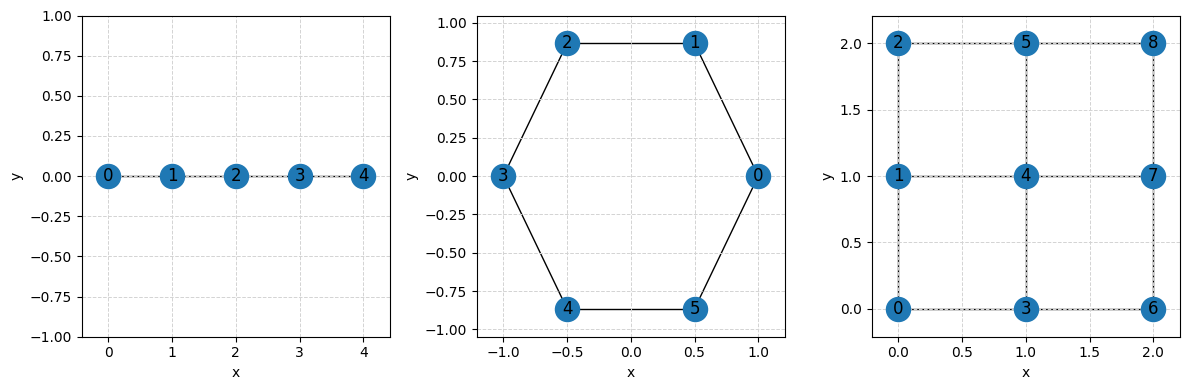

In [8]:
import matplotlib.pyplot as plt
from qoolqit import DataGraph

g_line = DataGraph.line(5)
g_circle = DataGraph.circle(n=6, spacing=1.0)
g_square = DataGraph.square(m=3, n=3)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
g_line.draw(ax=ax1)
g_circle.draw(ax=ax2)
g_square.draw(ax=ax3)

In [9]:
# ✅ Check
assert g_line.number_of_nodes() == 5
assert g_circle.number_of_nodes() == 6
assert g_square.number_of_nodes() == 9
print("All three graphs look right!")

All three graphs look right!


## 2. Abstract graphs vs. graphs with coordinates

Not every graph has coordinates. What is required is only their connectivity: edges and nodes. 
A **random Erdős–Rényi graph**, for
instance, is purely *abstract*: it defines which nodes are connected, but
says nothing about where the nodes sit in the plane. Since neutral atoms live
in real space, sooner or later every graph needs coordinates — that is the
job of *embedding* (Section 4).

Useful properties to interrogate a graph: `has_coords`, `has_edges`,
`has_node_weights`, `has_edge_weights`.

### ✏️ Exercise 1.2 — An abstract random graph

1. Create `g_er`, an Erdős–Rényi random graph with `n=8` nodes, edge
   probability `p=0.4` and `seed=3` (for reproducibility).
2. Print whether it has coordinates (`has_coords`) and how many edges it has.
3. Try to compute `g_er.min_distance()` inside a `try/except Exception` block
   and print the error — distances make no sense without coordinates!

In [4]:
g_er = DataGraph.random_er(n=8, p=0.4, seed=3)

print("Has coordinates:", g_er.has_coords)
print("Number of edges:", g_er.number_of_edges())

try:
    g_er.min_distance()
except AttributeError as err:
    print("As expected, this fails:", err)

Has coordinates: False
Number of edges: 10
As expected, this fails: Trying to compute distances for a graph without coordinates.


In [11]:
# ✅ Check
assert g_er.number_of_nodes() == 8
assert not g_er.has_coords, "An ER graph should be abstract (no coordinates)"
print("Correct — g_er is an abstract graph.")

Correct — g_er is an abstract graph.


## 3. Embedding: assign coordinates to an abstract graph or interaction matrix

**Embedding** is the process of assigning coordinates to a graph. QoolQit can take an
  abstract graph and return the same graph *with coordinates* or take a symmetric matrix of *desired interactions* and return a graph whose node positions physically realize them (next section).


### ✏️ Exercise 1.4 — Spring-layout embedding of the random graph

1. Import `SpringLayoutEmbedder` from `qoolqit.embedding` and instantiate it.
2. Embed the abstract graph `g_er` from Exercise 1.2 into `g_er_embedded`.
3. Verify the embedded graph now has coordinates, print its `min_distance()`,
   and draw it.

Has coordinates: True
Minimum distance: 0.820294932137076


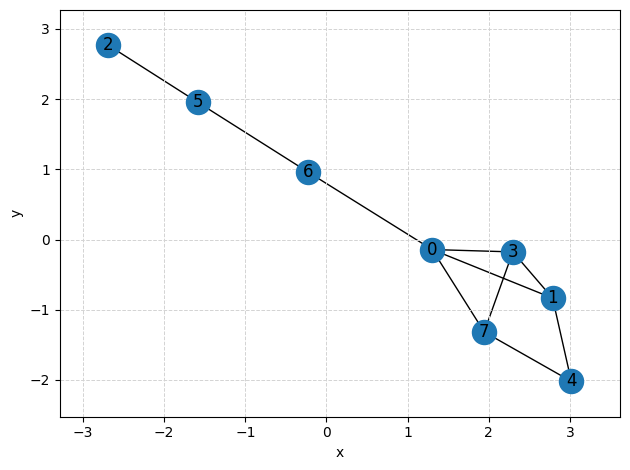

In [12]:
from qoolqit.embedding import SpringLayoutEmbedder

embedder = SpringLayoutEmbedder()
g_er_embedded = embedder.embed(g_er)

print("Has coordinates:", g_er_embedded.has_coords)
print("Minimum distance:", g_er_embedded.min_distance())
g_er_embedded.draw()

In [13]:
# ✅ Check
assert g_er_embedded.has_coords, "The embedded graph should have coordinates"
print("Spring-layout embedding successful!")

Spring-layout embedding successful!


### ✏️ Exercise 1.5 — Embed a target interaction matrix

1. Define the symmetric 3×3 target matrix
   `M = [[0, 1, 0.3], [1, 0, 0.5], [0.3, 0.5, 0]]` as a NumPy array.
2. Instantiate an `InteractionEmbedder` (from `qoolqit.embedding`) and embed
   `M` into `g_int`.
3. Draw `g_int`, then print its `interactions()` dictionary side by side with
   the corresponding entries of `M`. How close did the embedder get?

> 💡 The `interactions()` method computes $1/r^6$ for each pair of nodes from
> the coordinates.

pair (0,1):  J = 1.0000   target M = 1.0000
pair (0,2):  J = 0.3000   target M = 0.3000
pair (1,2):  J = 0.5000   target M = 0.5000


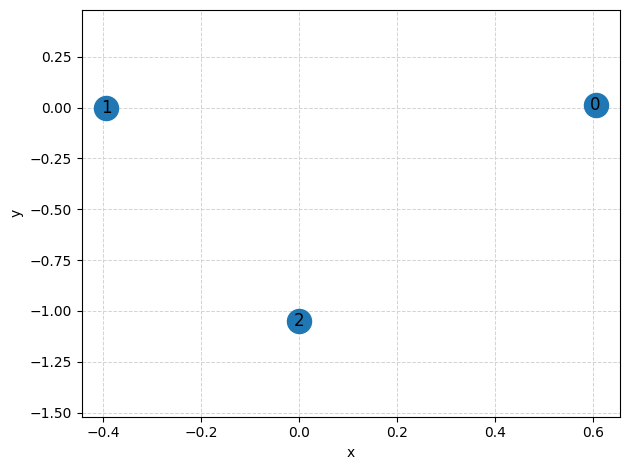

In [14]:
import numpy as np
from qoolqit.embedding import InteractionEmbedder

M = np.array([[0.0, 1.0, 0.3], [1.0, 0.0, 0.5], [0.3, 0.5, 0.0]])

g_int = InteractionEmbedder().embed(M)

g_int.draw()

for (i, j), J in g_int.interactions().items():
    print(f"pair ({i},{j}):  J = {J:.4f}   target M = {M[i, j]:.4f}")

# For 3 nodes the embedder reproduces the targets almost exactly:
# the strongest coupling (1.0) corresponds to the closest pair of atoms.

In [15]:
# ✅ Check — every realized interaction within 5% of its target
for (i, j), J in g_int.interactions().items():
    assert abs(J - M[i, j]) < 0.05, f"pair ({i},{j}) is off: {J} vs {M[i, j]}"
print("Interaction embedding matches the target matrix!")

Interaction embedding matches the target matrix!


### Next module
Graphs describe *data* and *geometry*. In **Module 2** we turn geometry into
physics: the `Register` of atoms, the time-dependent `Drive`, and the
`QuantumProgram` that combines them.